# <span style="color:darkblue"> Assignment 3 </span>

<font size = "5">


In [ ]:
# Import packages
import requests
import json
import jmespath
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt

# <span style="color:darkred"> Question 1 </span>

<font size = "4">

How many works have “artificial intelligence” in the title?

# <span style="color:orange"> Approach 1 </span>

<font size = "4">

To count works that have "artificial intelligence" in the title, I first constructed a query URL that retrieves all works containing "artificial intelligence" in their titles. I then used the requests to send the query and obtain the results in json format. 

Based on the json document, I can count the results from meta field. I stored the results which include all works with "artificial intelligence" in the title for future reference.

In [17]:
# Search for all the works that have "artificial intelligence" in the title
url = "https://api.openalex.org/works?filter=title.search:artificial%20intelligence"
# convert to json file
search_results = requests.get(url).json()

# Count how many works have "artificial intelligence" in the title
count_ai = search_results['meta']['count']

# Opens the file to write it
with open('AI_search_results.json', 'w') as file: 
    file.write(json.dumps(search_results, indent =4))

count_ai

198258

# <span style="color:darkgreen"> Answer 1 </span>

<font size = "4">

Based on the api searching results, there are **198,258** works with “artificial intelligence” in the title on OpenAlex.



# <span style="color:DarkRed"> Question 2 </span>

<font size = "4">

Filter years since 2020 and group by the country of the author’s affiliation. Produce a
table which sorts the countries by number of publications about artificial intelligence.

# <span style="color:orange"> Approach 2 </span>

<font size = "4">

I wrote a URL query that filters works containing “artificial intelligence” in the title and were published after 2020. I also grouped the works by countries in the institution field in the sense that OpenAlex API can automatically aggregate works by country and counted the number of publications for each country. I then retrieved and stored the results in json format. 

I extracted the country information and work counts from the group_by, and I converted them into a DataFrame and sorted the data in descending order by the number of publications.

In [19]:
# Filter works after 2020 and include "artificial intelligence" in the title
url2020 = "https://api.openalex.org/works?filter=title.search:artificial%20intelligence,from_publication_date:2020-01-01&group_by=institutions.country_code"

results_ai_2020 = requests.get(url2020).json()

# Write and save the json file
with open('results_ai_2020.json', 'w') as file: 
    file.write(json.dumps(results_ai_2020, indent =4))

group_results = results_ai_2020.get("group_by", [])

country_counts = pd.DataFrame(group_results)
country_counts.columns = ["url", "country", "num_publications"]
country_counts.sort_values(by="num_publications", ascending=False)
country_counts

,url,country,num_publications
0,https://openalex.org/countries/US,United States of America,20205
1,https://openalex.org/countries/CN,China,15735
2,https://openalex.org/countries/IN,India,11153
3,https://openalex.org/countries/GB,United Kingdom of Great Britain and Northern I...,6807
4,https://openalex.org/countries/IT,Italy,4127
...,...,...,...
188,https://openalex.org/countries/GL,Greenland,1
189,https://openalex.org/countries/GN,Guinea,1
190,https://openalex.org/countries/HT,Haiti,1
191,https://openalex.org/countries/NC,New Caledonia,1


# <span style="color:darkgreen"> Answer 2 </span>

<font size = "4">

Based on the table, we can see that the **United States of America** has the largest number of published works with “artificial intelligence” in the title, which is **20,205**, followed by **China** with **15,735** publications and **India** with **11,153**. It should also be noted that the results do not include works for which the country code is missing.

# <span style="color:darkred"> Question 3 </span>

<font size = "4">

What are the names of the 10 most highly cited papers on artificial intelligence since
2020? How many citations do they have? What are the authors? What institutions are
they affiliated with?

# <span style="color:orange"> Approach 3 </span>

<font size = "4">

I wrote a URL query that filters for works containing “artificial intelligence” in the title and were published after 2020. I retrieved and sorted the works by the parameter cited_by_count which is the number of citations in descending order. I then selected the top ten most cited works. 

To extract information including titles, citations, author names and institutions, I wrote a nested loop that retrieved each work’s data from the filtered json document.I converted into a DataFrame and produced a table listing information of the ten most cited works.

In [28]:
url2020cite = "https://api.openalex.org/works?filter=title.search:artificial%20intelligence,from_publication_date:2020-01-01"
cite_ai_2020 = requests.get(url2020cite).json()
works = cite_ai_2020["results"]
sorted_works = sorted(works, key=lambda x: x.get("cited_by_count", 0), reverse=True)
work_10 = sorted_works[:10]

list_10 = []
# Extract information of title, number of citations, authors, and institutions
for work in work_10:
    title = work.get("title", "")
    citations = work.get("cited_by_count", 0)

    authors = []
    institution = []
    for authorship in work.get("authorships", []):
        authorname = authorship.get("author", {}).get("display_name", "")
        if authorname:
            authors.append(authorname)

        # For institutions, I will extract the institution names and the countries
        for ins in authorship.get("institutions", []):
            affiliation = ins.get("display_name", "")
            country_code = ins.get("country_code", "")
            if affiliation:
                institution.append(f"{affiliation}, {country_code}")
    
    list_10.append({
        "title": title,
        "citations": citations,
        # I wrote "join' to include all the authors and institutions for each work
        "author": "; ".join(authors),
        "institutions": "; ".join(institution)
    })

data10 = pd.DataFrame(list_10)
data10

,title,citations,author,institutions
0,Artificial Intelligence in Education: A Review,2267,Lijia Chen; Pingping Chen; Zhijian Lin,"Yango University, CN; Fuzhou University, CN; F..."
1,The role of artificial intelligence in achievi...,2195,Ricardo Vinuesa; Hossein Azizpour; Iolanda Lei...,"Swedish e-Science Research Centre, SE; KTH Roy..."
2,Using Artificial Intelligence to Detect COVID-...,1956,Lin Li; Lixin Qin; Zeguo Xu; Youbing Yin; Xin ...,"Jianghan University, CN; Wuhan Pulmonary Hospi..."
3,Revolutionizing healthcare: the role of artifi...,1629,Shuroug A. Alowais; Sahar S. Alghamdi; Nada Al...,King Saud bin Abdulaziz University for Health ...
4,A Survey on Explainable Artificial Intelligenc...,1560,Erico Tjoa; Cuntai Guan,"Alibaba Group (China), CN; Nanyang Technologic..."
5,Human Trust in Artificial Intelligence: Review...,1419,Ella Glikson; Anita Williams Woolley,"Bar-Ilan University, IL; Carnegie Mellon Unive..."
6,Artificial Intelligence (AI) applications for ...,1416,Raju Vaishya; Mohd Javaid; Ibrahim Haleem Khan...,"Indraprastha Apollo Hospitals, IN; Jamia Milli..."
7,Photonics for artificial intelligence and neur...,1399,Bhavin J. Shastri; Alexander N. Tait; Thomas F...,"Queen's University, CA; Princeton University, ..."
8,Review of Artificial Intelligence Techniques i...,1396,Feng Shi; Jun Wang; Jun Shi; Ziyan Wu; Qian Wa...,"United Imaging Healthcare (China), CN; Shangha..."
9,Explainability for artificial intelligence in ...,1236,Julia Amann; Alessandro Blasimme; Effy Vayena;...,"ETH Zurich, CH; ETH Zurich, CH; ETH Zurich, CH..."


# <span style="color:darkgreen"> Answer 3 </span>

<font size = "4">

The table above summarizes the titles, citation counts, authors, and institutions of the top ten most cited works. 

For example, the most cited work is *Artificial Intelligence in Education: A Review* by Lijia Chen, Pingping Chen, and Zhijian Lin, which has a total of **2,267** citations. The second most cited work is *The Role of Artificial Intelligence in Achieving the Sustainable Development Goals*, with **2,195** citations. This is followed by *Using Artificial Intelligence to Detect COVID-19 and Community-acquired Pneumonia Based on Pulmonary CT: Evaluation of the Diagnostic Accuracy*, which has **1,956** citations.


# <span style="color:darkred"> Question 4 </span>

<font size = "4">

How has the number of publications with the word “artificial intelligence” changed year-
to-year since 2000? How does this compare to the usage of the word “LLM” or “GPT”?
Do the analysis for another keyword of your interest. Plot your results in a graph.

# <span style="color:orange"> Approach 4 </span>

<font size = "4">

To compare the publication trends after 2000, I wrote three URL queries that filter for works have “artificial intelligence”, “LLM”, and “GPT” in the text and that were published after 2000. For each query, I added the parameter group_by=publication_year so that the OpenAlex API would aggregate the results by year and return the number of publications. 

I then converted the group_by field from each json response into a DataFrame and sorted the years. I plotted the publication trends for each keyword separately to see the trend and combined them into a single figure to compare the overall patterns.

*It should be noticed that we are looking at papers including "artificial intelligence", "LLM", "GPT" in their text, not just in the title.*

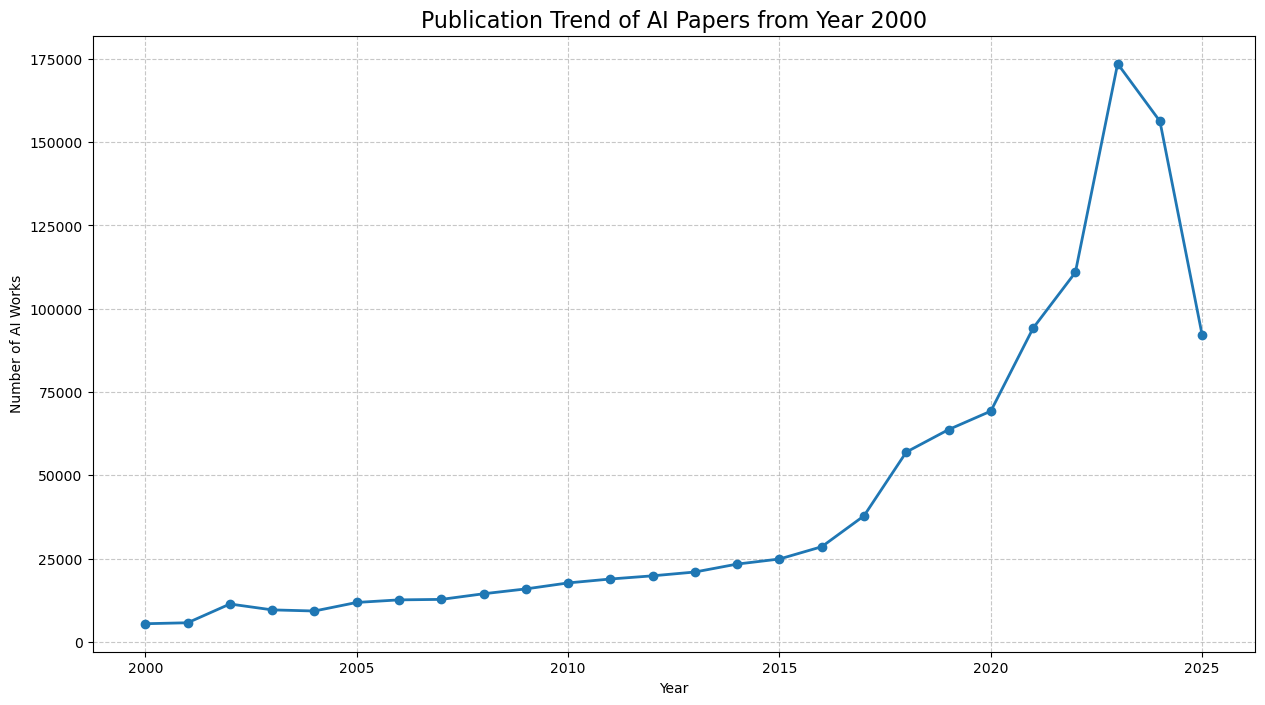

In [21]:
# Filter for works related to artificial intelligence and was published after 2000
# Store the data in json format
url_ai = "https://api.openalex.org/works?filter=from_publication_date:2000-01-01&search=artificial intelligence&group_by=publication_year"
search_ai = requests.get(url_ai).json()
# Opens the file to write it
with open('search_ai.json', 'w') as file: 
    file.write(json.dumps(search_ai, indent =4))

# Call group by year data
# Convert to dataframe, rename 
# and sort by year
group_by_year = search_ai["group_by"]
year_counts = pd.DataFrame(group_by_year)
year_counts = year_counts.rename(columns={"key": "year", "count": "num_publications"})
year_counts["year"] = pd.to_numeric(year_counts["year"])
year_counts = year_counts.sort_values("year")

# Draw plot figure
plt.figure(figsize=(15, 8))
plt.plot(year_counts["year"], year_counts["num_publications"], marker="o", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Number of AI Works")
plt.title("Publication Trend of AI Papers from Year 2000", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()



<font size = "4">

**Publication Trend of AI Papers from Year 2000**

This figure shows the publication trend of papers mentioning AI. We found that from 2000 to 2015, the number of AI-related papers increased steadily. But after 2016, the number of publications increased rapidly, surging in 2022 and reaching a peak of around 175,000 publications at 2023. A slight decline appears in the following years, but the decrease observed in 2025 is most likely due to incomplete indexing, as many papers from this year may not yet have been collected or published.

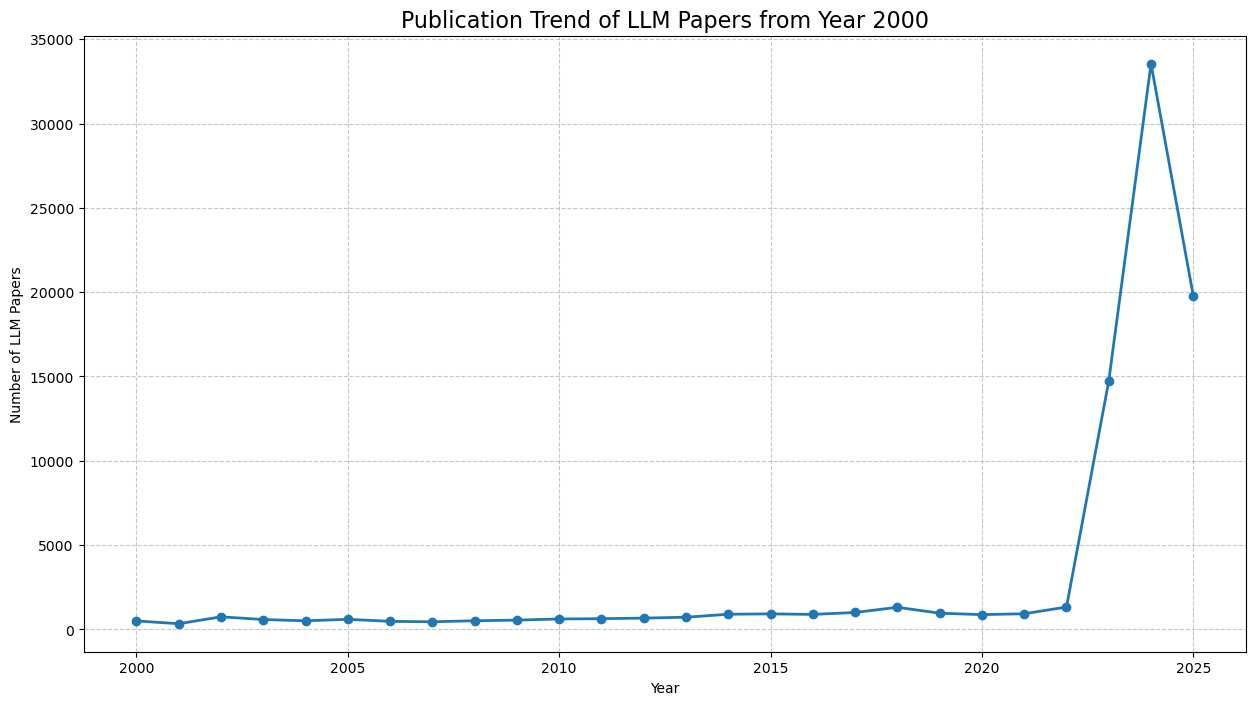

In [22]:
# Filter for works related to LLM and was published after 2000
# Store the data in json format
url_llm = "https://api.openalex.org/works?filter=from_publication_date:2000-01-01&search=llm&group_by=publication_year"
search_llm = requests.get(url_llm).json()

# Opens the file to write it
with open('search_llm.json', 'w') as file: 
    file.write(json.dumps(search_llm, indent =4))

# Call group by year data
# Convert to dataframe, rename 
# and sort by year
group_year_llm = search_llm["group_by"]
year_llm = pd.DataFrame(group_year_llm)
llm_counts = year_llm.rename(columns={"key": "year", "count": "num_publications"})
llm_counts["year"] = pd.to_numeric(llm_counts["year"])
llm_counts = llm_counts.sort_values("year")

# Draw plot figure
plt.figure(figsize=(15, 8))
plt.plot(llm_counts["year"], llm_counts["num_publications"], marker="o", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Number of LLM Papers")
plt.title("Publication Trend of LLM Papers from Year 2000", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

<font size = "4">

**Publication Trend of LLM Papers from Year 2000**

No significant change in the number of LLM-related papers was observed between 2000 and 2017. In 2018, the number started to increase, and it surged dramatically in 2022, rising from around 1,000 to 15,000 publications. The trend reached its peak in 2024 with nearly 34,000 publications. A decline is also observed in 2025, which is likely due to to unpublished or unindexed works that have not yet been fully recorded rather than a real decrease.

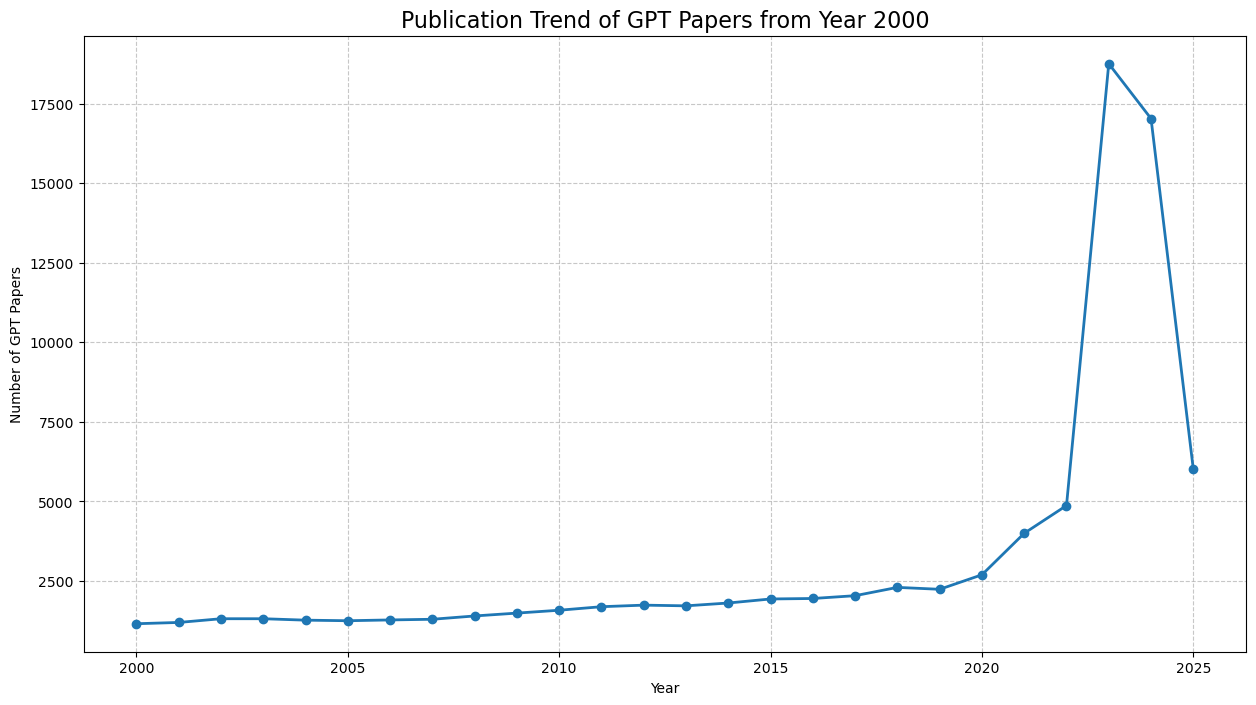

In [23]:
# Filter for works related to GPT and was published after 2000
# Store the data in json format
url_gpt = "https://api.openalex.org/works?filter=from_publication_date:2000-01-01&search=gpt&group_by=publication_year"
search_gpt = requests.get(url_gpt).json()

# Opens the file to write it
with open('search_gpt.json', 'w') as file: 
    file.write(json.dumps(search_gpt, indent =4))

# Call group by year data
# Convert to dataframe, rename 
# and sort by year
group_year_gpt = search_gpt["group_by"]
year_gpt = pd.DataFrame(group_year_gpt)
gpt_counts = year_gpt.rename(columns={"key": "year", "count": "num_publications"})
gpt_counts["year"] = pd.to_numeric(gpt_counts["year"])
gpt_counts = gpt_counts.sort_values("year")

# Draw plot figure
plt.figure(figsize=(15, 8))
plt.plot(gpt_counts["year"], gpt_counts["num_publications"], marker="o", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Number of GPT Papers")
plt.title("Publication Trend of GPT Papers from Year 2000", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

<font size = "4">

**Publication Trend of GPT Papers from Year 2000**

From 2000 to 2019, a steady and slow growth can be observed from the figure. In 2022, the number of GPT-related papers saw a dramatic surge, reaching a peak of nearly 18,000 in 2023. The decline observed after 2024 is also likely due to unidexed and unpulished works in 2025


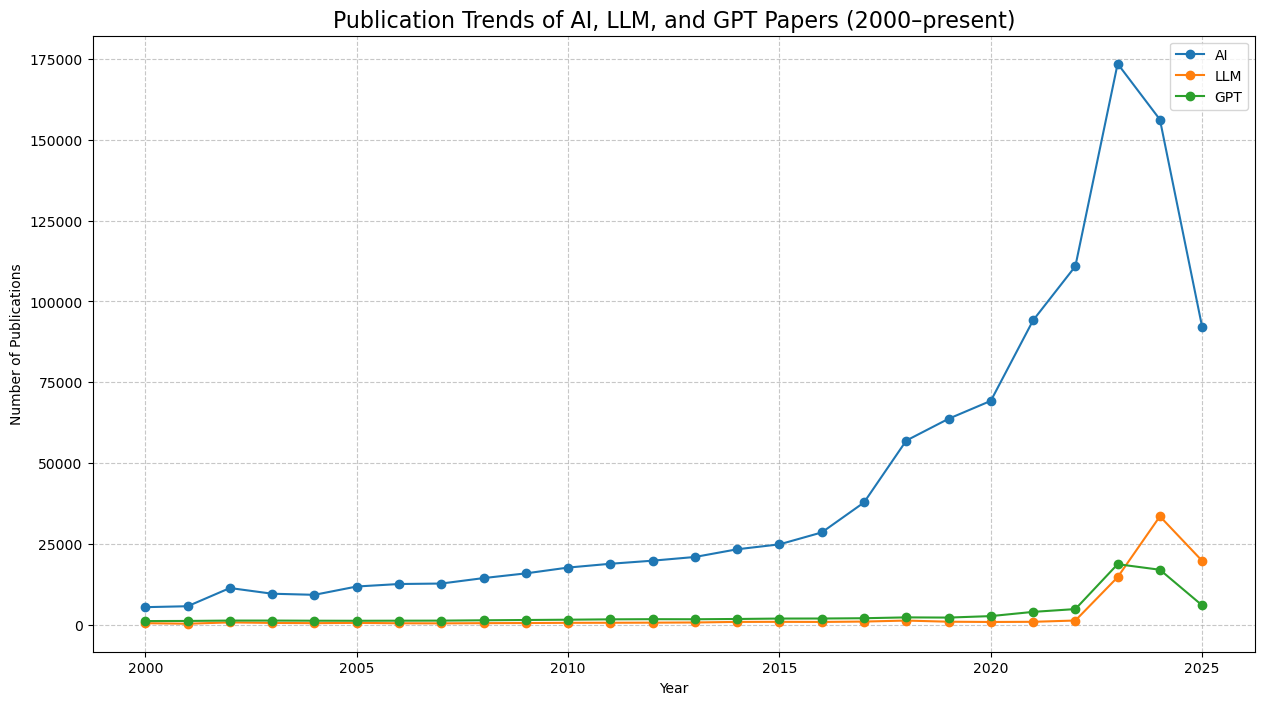

In [26]:
plt.figure(figsize=(15, 8))
plt.plot(year_counts["year"], year_counts["num_publications"], marker="o", label="AI")
plt.plot(llm_counts["year"], llm_counts["num_publications"], marker="o", label="LLM")
plt.plot(gpt_counts["year"], gpt_counts["num_publications"], marker="o", label="GPT")
plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.title("Publication Trends of AI, LLM, and GPT Papers (2000–present)", fontsize=16)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

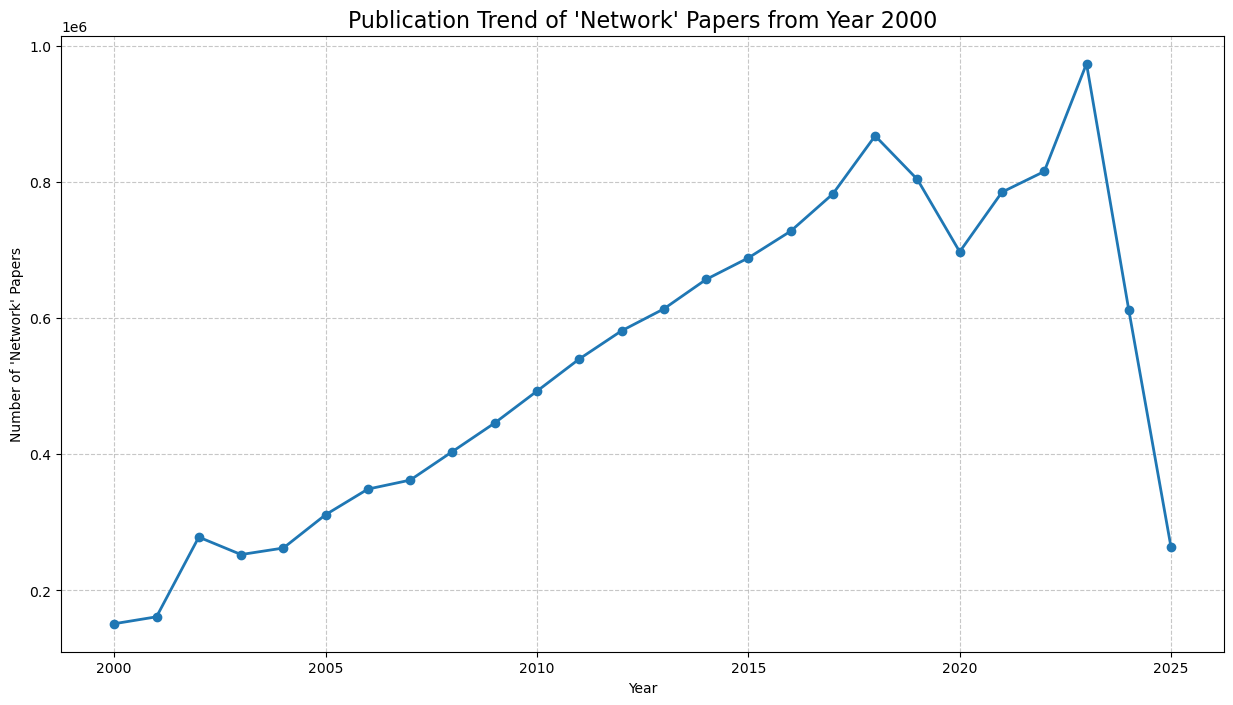

In [32]:
# Filter for works related to "network" and published after 2000
url_network = "https://api.openalex.org/works?filter=from_publication_date:2000-01-01&search=network&group_by=publication_year"
search_network = requests.get(url_network).json()

# Store the json file
with open('search_network.json', 'w') as file: 
    file.write(json.dumps(search_network, indent=4))

# Call group by year data
# Convert to dataframe, rename 
# and sort by year
group_year_network = search_network["group_by"]
year_network = pd.DataFrame(group_year_network)
network_counts = year_network.rename(columns={"key": "year", "count": "num_publications"})
network_counts["year"] = pd.to_numeric(network_counts["year"])
network_counts = network_counts.sort_values("year")

# Draw plot figure
plt.figure(figsize=(15, 8))
plt.plot(network_counts["year"], network_counts["num_publications"], marker="o", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Number of 'Network' Papers")
plt.title("Publication Trend of 'Network' Papers from Year 2000", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# <span style="color:darkgreen"> Answer 4 </span>

<font size = "4">

From the combined figure, LLM and GPT related publications show very similar patterns, both experiencing rapid growth in 2022. This is intuitive, as GPT can be considered one of the key accomplishments of LLM research. After 2023, however, the two trends diverge: LLM related papers continue to increase rapidly, while GPT related publications show a slight decline, suggesting that attention may have shifted to other types of large language models. Compared with LLM and GPT works, AI related papers maintain dominance in volume, with steady growth from 2000 to 2016 and accelerated growth thereafter.

The number of publications containing the word “network” has been consistently high compared with AI, LLM, and GPT. From 2000 to around 2015, the trend shows a steady increase, rising from roughly 100,000 to almost 700,000 publications. The growth reached its peak in 2018 with nearly 900,000 publications. Afterward, some fluctuations are observed: a temporary decline between 2018 and 2020, followed by another rise till 2022, and a sharp drop in 2023. Still, compared with works of GPT, LLM and AI, network papers remain a substantive volume, which can be explained by its wide usage across multiple disciplines, including computer science, sociology, economics and biology.

